<a href="https://colab.research.google.com/github/EthanTong123/Quantum_Metal_designs/blob/main/design_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==1.26.4
!pip install -q quantum-metal

In [ ]:
import qiskit_metal as qm
import matplotlib.pyplot as plt
from qiskit_metal import designs
from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal import Dict

from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import (
    LaunchpadWirebondCoupled,
)
from collections import OrderedDict
import numpy as np

In [ ]:
design = designs.DesignPlanar()
design.overwrite_enabled = True
gui = qm.gui(design)

design.chips['main']['size']['size_x'] = '1mm'
design.chips['main']['size']['size_y'] = '1mm'

09:24PM 25s INFO [_start_renderers]: Renderer=hfss skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').
09:24PM 25s INFO [_start_renderers]: Renderer=q3d skipped: runtime dependency not installed (QAnsysRenderer requires pyEPR. Install with: pip install 'quantum-metal[ansys]').
09:24PM 25s INFO [_start_renderers]: Renderer=gmsh skipped: runtime dependency not installed (renderer_gmsh requires gmsh. Install with: pip install 'quantum-metal[mesh]' (or the legacy alias 'quantum-metal[fem]')).
09:24PM 25s INFO [_start_renderers]: Renderer=aedt_q3d skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').
09:24PM 25s INFO [_start_renderers]: Renderer=aedt_hfss skipped: runtime dependency not installed (QPyaedt requires pyaedt (ansys.aedt.core). Install with: pip install 'quantum-metal[ansys]').


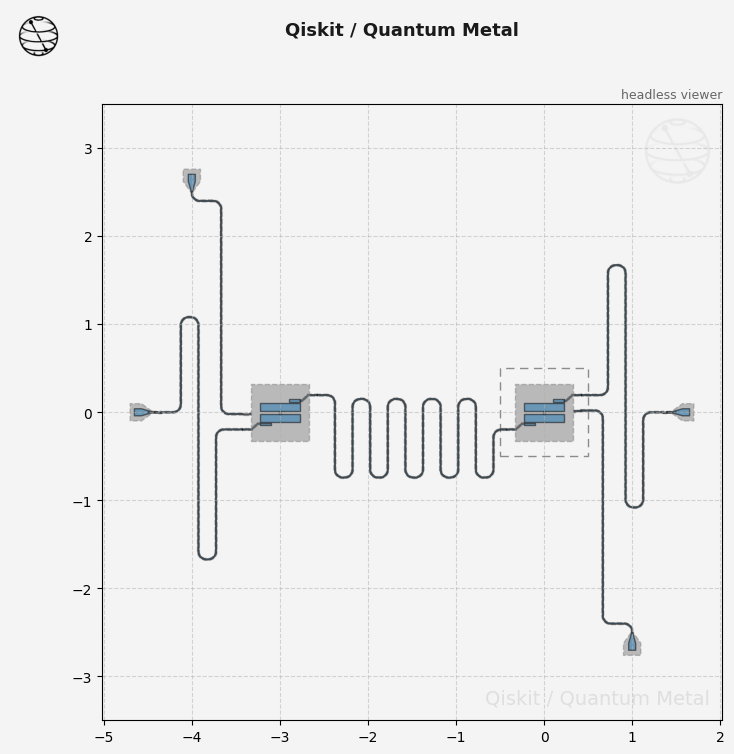

In [ ]:
options = dict(
    connection_pads = dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=-1),
    ),
    cl_off_center="-25um",
)

q1 = TransmonPocketCL(design, "Q1", options=dict(cl_pocket_edge = 180, **options))
q2 = TransmonPocketCL(design, "Q2", options=dict(pos_x="-3mm", **options))

def connect(name, c1, p1, c2, p2, length, start_straight="0um", asym="0 um"):

    return RouteMeander(
        design,
        name,
        Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=c1, pin=p1), end_pin=Dict(component=c2, pin=p2)
            ),
            lead=Dict(start_straight=start_straight),
            total_length=length,
            fillet="90um",
            meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry=asym),
        ),
    )


cpw1 = connect("cpw1", "Q1", "b", "Q2", "a","10.0mm","0.15mm" ,"100um")

gui.autoscale()
gui.rebuild()

09:24PM 27s WARNING [check_lengths]: For path table, component=cpw1, key=trace has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.
09:24PM 27s WARNING [check_lengths]: For path table, component=cpw1, key=cut has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


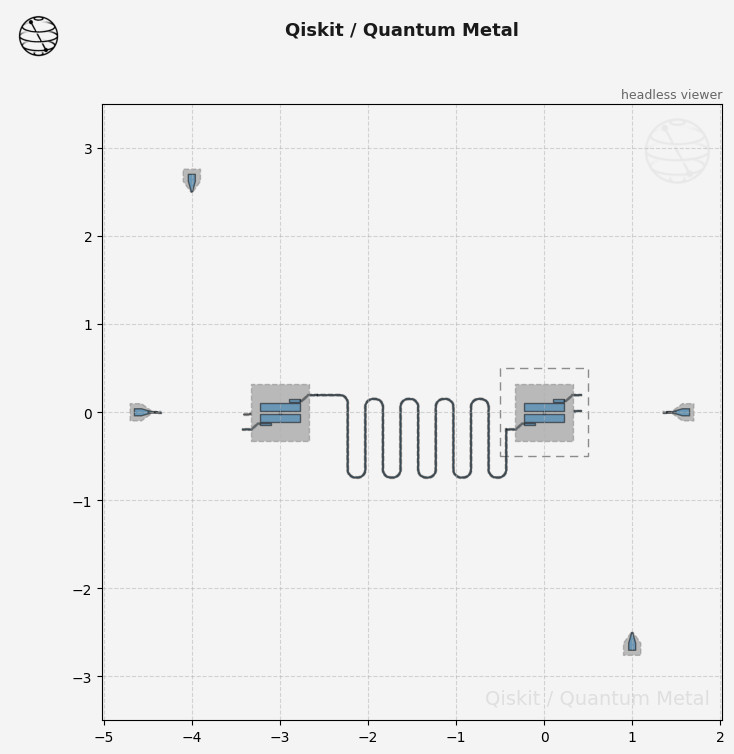

In [ ]:
# Wirebonds or sum - The corner ones, connects to chargeline
p1_c = LaunchpadWirebond(
    design,
    "P1_C",
    options=dict(pos_x="1mm", pos_y="-2.5mm", orientation="90", lead_length="0um"),
)
p2_c = LaunchpadWirebond(
    design,
    "P2_C",
    options=dict(pos_x="-4mm", pos_y="+2.5mm", orientation="270", lead_length="0um"),
)

# Exchange Coupler Lines to Edges
p1_q = LaunchpadWirebondCoupled(
    design,
    "P1_Q",
    options=dict(pos_x="1.45mm", pos_y="0", orientation="180", lead_length="30um"),
)
p2_q = LaunchpadWirebondCoupled(
    design,
    "P2_Q",
    options=dict(pos_x="-4.45mm", pos_y="0", orientation="0", lead_length="30um"),
)


gui.rebuild()

09:24PM 29s WARNING [check_lengths]: For path table, component=cpw1, key=trace has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.
09:24PM 29s WARNING [check_lengths]: For path table, component=cpw1, key=cut has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


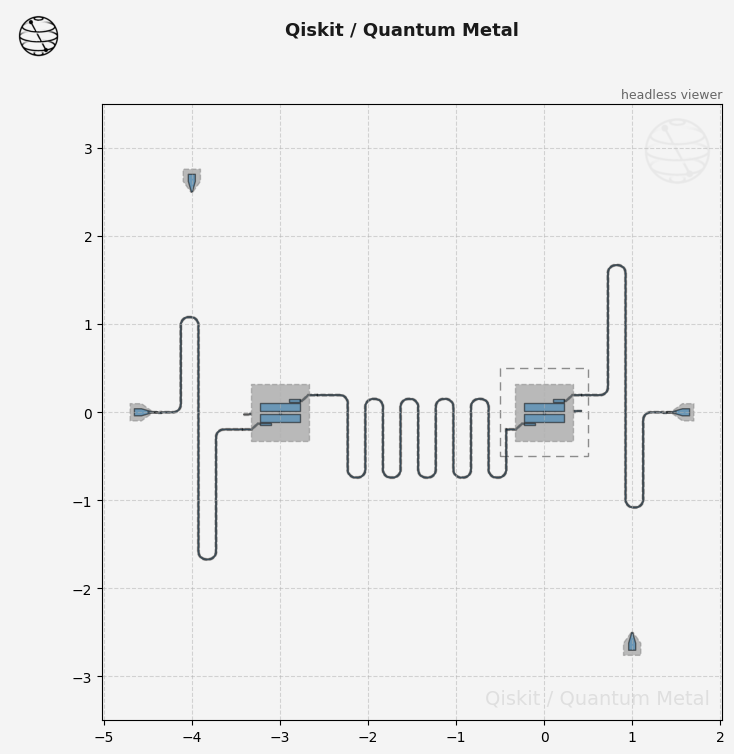

In [ ]:
# Connect Coupler Lines to Edges
ol1 = connect("ol1", "Q1", "a","P1_Q", "tie", "6mm", ".3mm","100um")
ol2 = connect("ol2", "Q2", "b","P2_Q", "tie", "6mm", ".3mm","100um")

gui.rebuild()

10:13PM 34s WARNING [check_lengths]: For path table, component=cpw1, key=trace has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.
10:13PM 34s WARNING [check_lengths]: For path table, component=cpw1, key=cut has short segments that could cause issues with fillet. Values in (1-1)  are index(es) in shapely geometry.


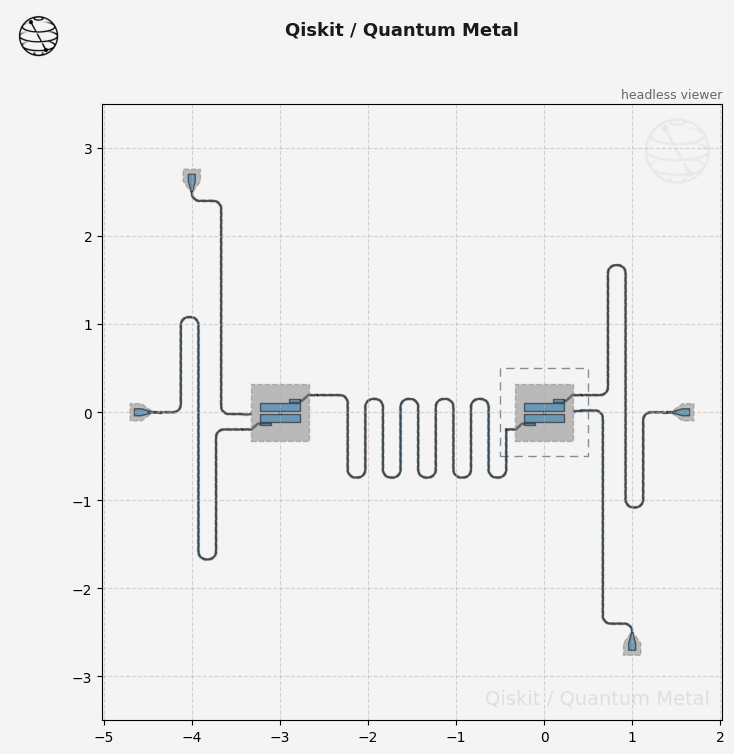

In [ ]:
#Chargelines to Corner
jogsB_in = OrderedDict()
# jogsB_in[0] = ["R", "0mm"]

# anchors = OrderedDict()
# anchors[0] = np.array([0.6, -2.5])
# anchors[1] = np.array([0.6, 0])

options_line_cl1 = {
    "pin_inputs": {
        "start_pin": {"component": "Q1", "pin": "Charge_Line"},
        "end_pin": {"component": "P1_C", "pin": "tie"},
    },
    "lead": {
        "start_straight": "0.25 mm",
        "end_straight": "0.1 mm",
    },
     "fillet" : "90 um"
}
cl1 = RouteAnchors(design, "line_cl1", options_line_cl1)

options_line_cl2 = {
    "pin_inputs": {
        "start_pin": {"component": "Q2", "pin": "Charge_Line"},
        "end_pin": {"component": "P2_C", "pin": "tie"},
    },
    "lead": {
        "start_straight": "0.25 mm",
        "end_straight": "0.1 mm",
    },
     "fillet" : "90 um"
}
cl2 = RouteAnchors(design, "line_cl2", options_line_cl2)

gui.rebuild()
gui.autoscale()

In [ ]:
#design.components['Q1'].options.connection_pads.keys()
#RouteAnchors.get_template_options(design)

dict_keys(['a', 'b'])

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'anchors': {},
 'advanced': {'avoid_collision': 'false'}}